In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
data=pd.read_csv('/content/insurance_prediction.csv')

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.shape

(1338, 7)

In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.describe(include='object').T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
data=data.drop_duplicates()

In [ ]:
data.shape

(1337, 7)

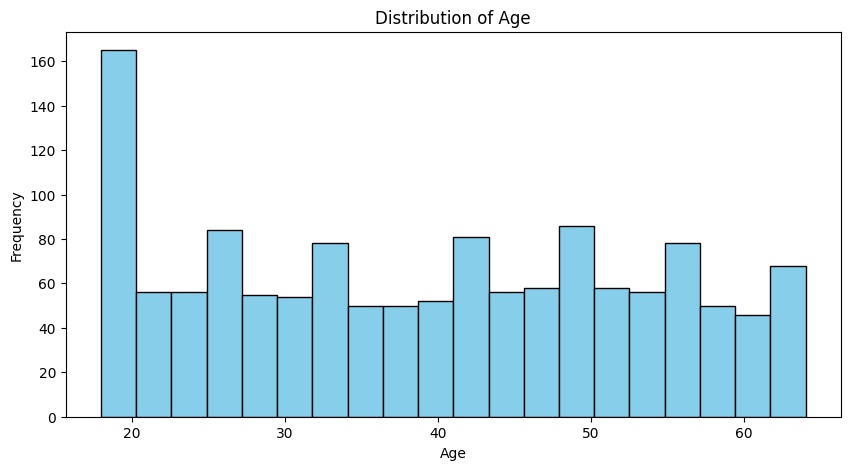

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

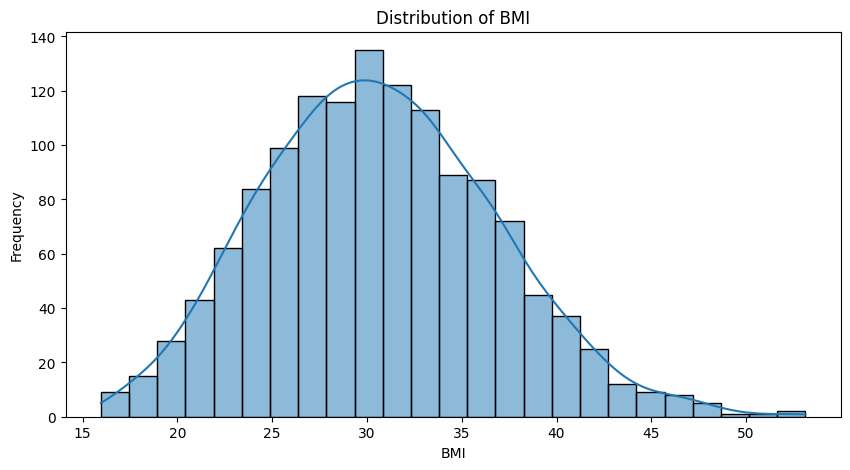

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['bmi'], kde=True)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Distribution of BMI')
plt.show()

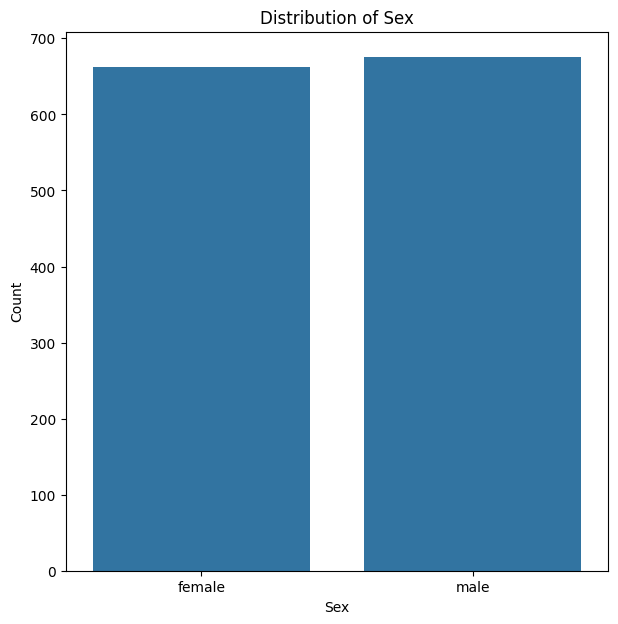

In [ ]:
plt.figure(figsize=(7,7))
sns.countplot(data=data, x='sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Sex')
plt.show()

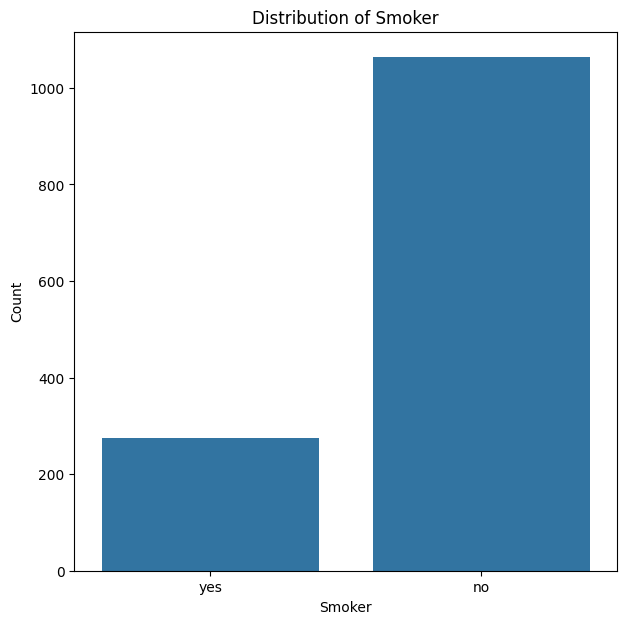

In [ ]:
plt.figure(figsize=(7,7))
sns.countplot(data=data, x='smoker')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.title('Distribution of Smoker')
plt.show()

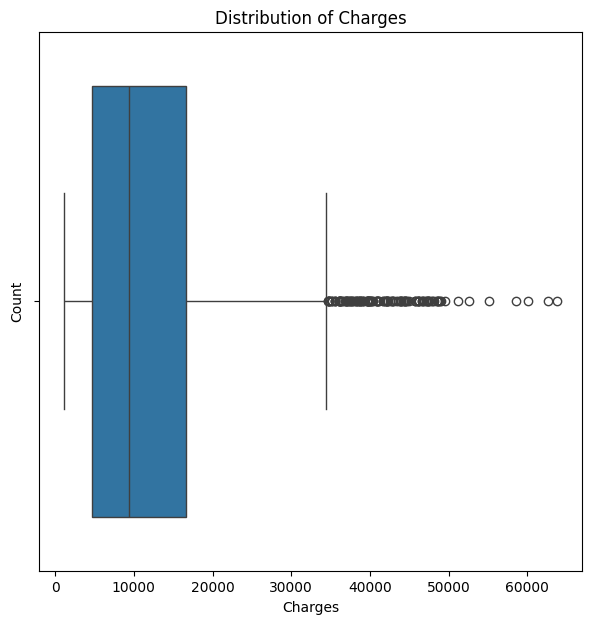

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=data, x='charges')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.title('Distribution of Charges')
plt.show()

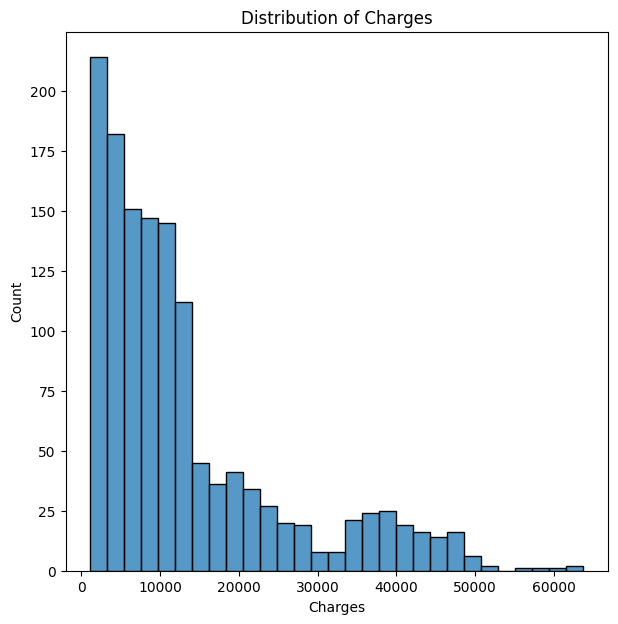

In [ ]:
plt.figure(figsize=(7,7))
sns.histplot(data=data, x='charges')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.title('Distribution of Charges')
plt.show()

Text(0.5, 1.0, 'Age vs Charges')

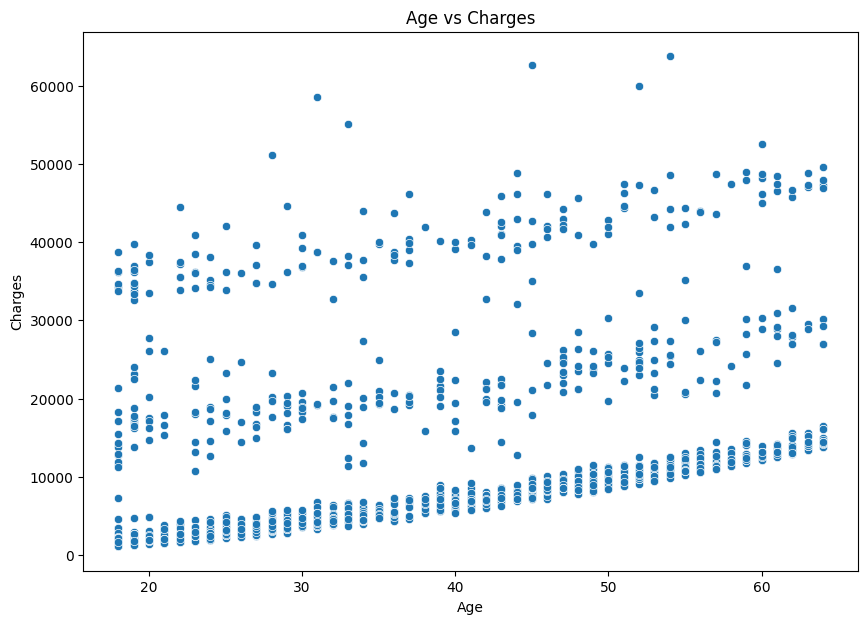

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='age', y='charges', data=data)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')

Text(0.5, 1.0, 'Smoker vs Charges')

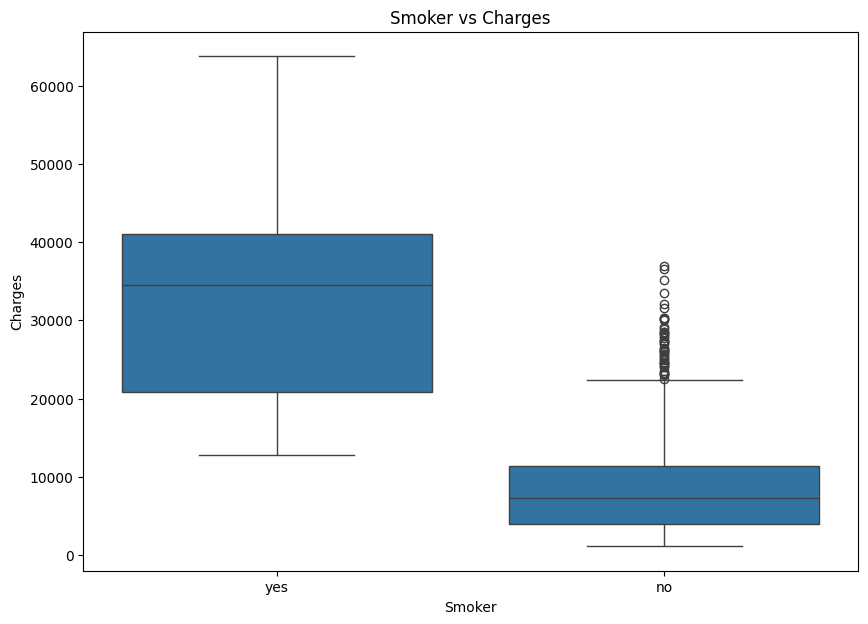

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='smoker', y='charges', data=data)
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.title('Smoker vs Charges')

Text(0.5, 1.0, 'Sex vs Charges')

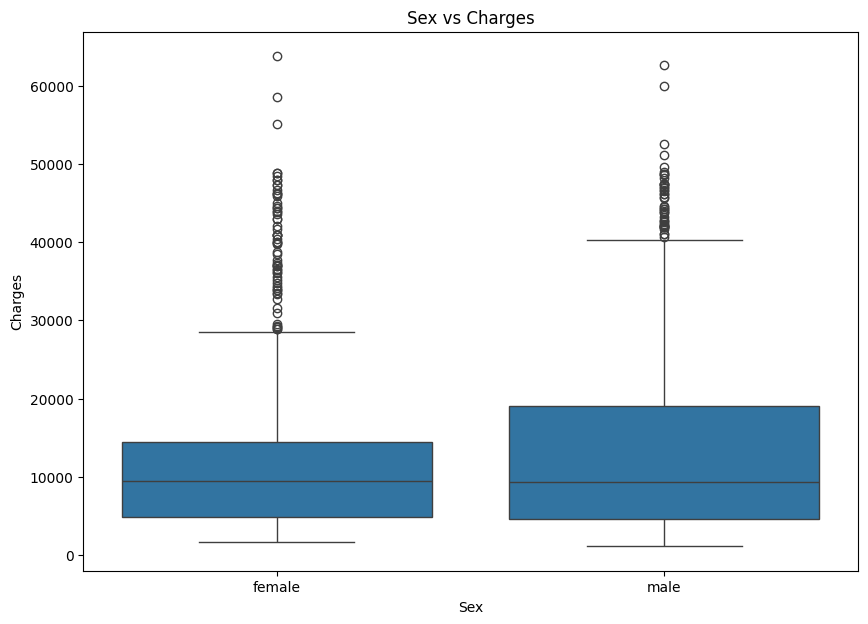

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='sex', y='charges', data=data)
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.title('Sex vs Charges')

Text(0.5, 1.0, 'Sex vs Charges')

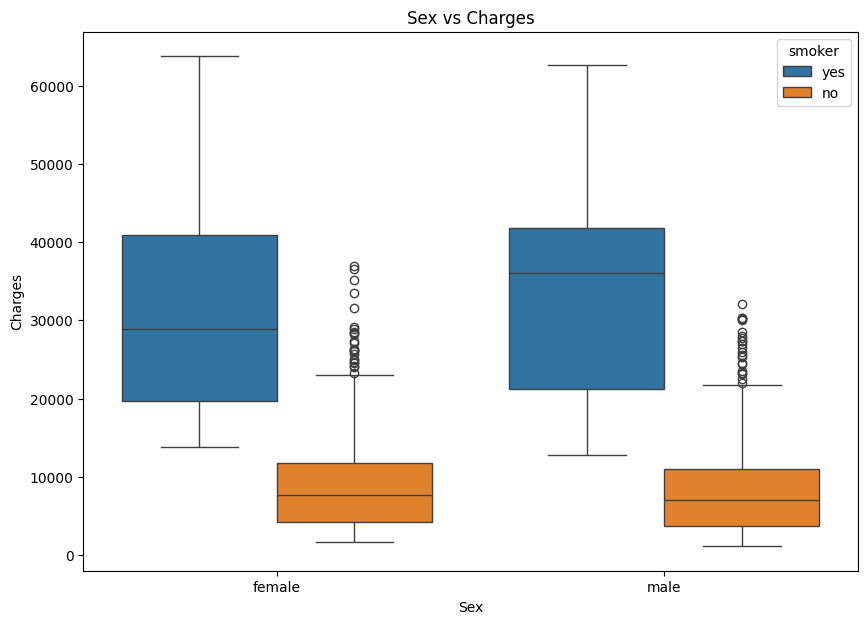

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.title('Sex vs Charges')

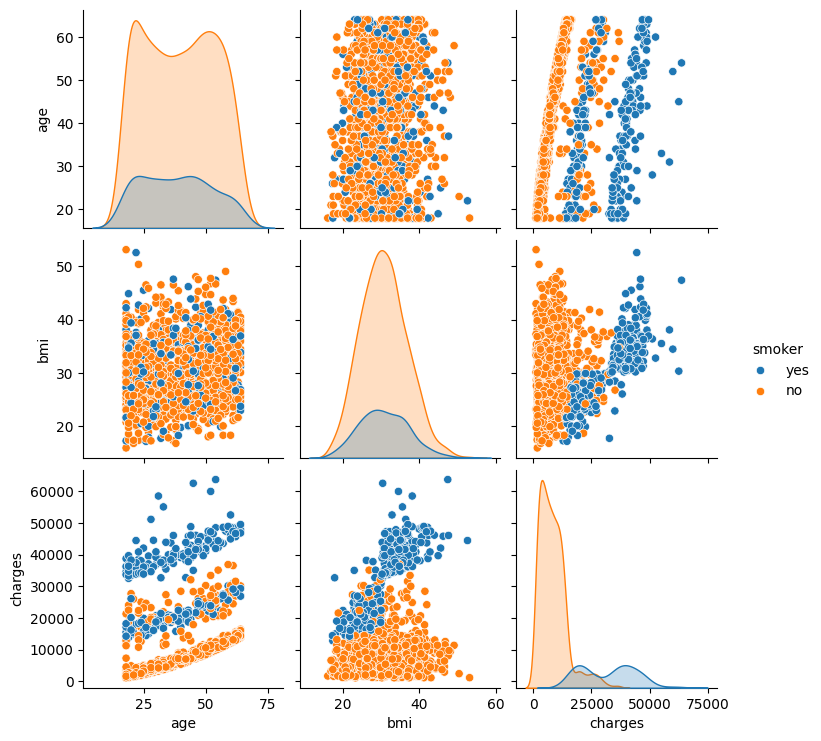

In [ ]:
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()

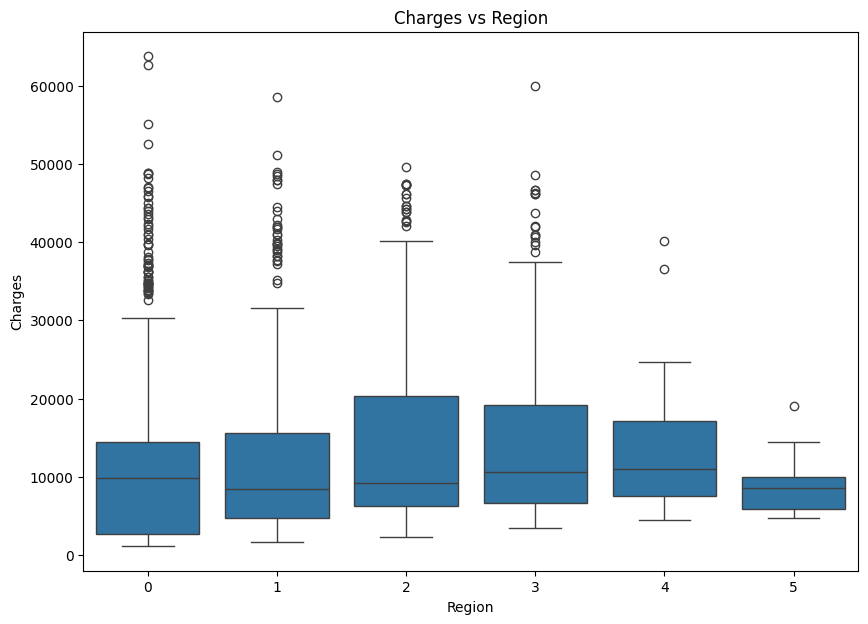

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='children', y='charges', data=data)
plt.xlabel('Region')
plt.ylabel('Charges')
plt.title('Charges vs Region')
plt.show()

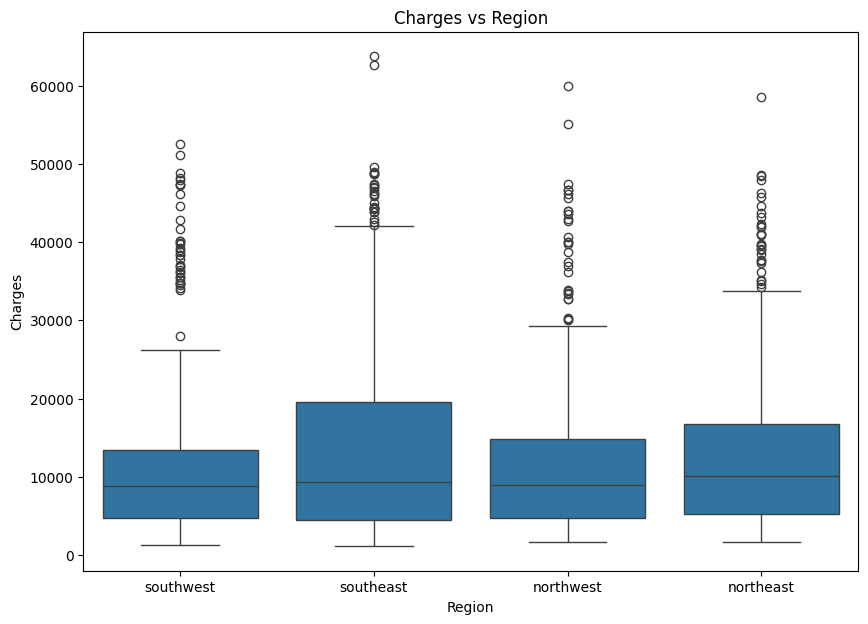

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='region', y='charges', data=data)
plt.xlabel('Region')
plt.ylabel('Charges')
plt.title('Charges vs Region')
plt.show()

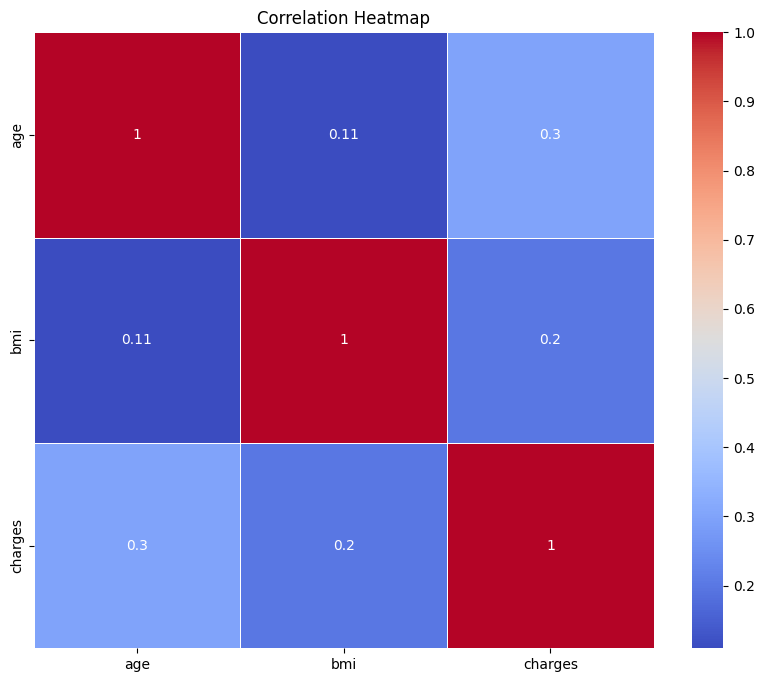

In [ ]:
numericals = ['age', 'bmi', 'charges']
correlation_matrix = data[numericals].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
data=pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

In [ ]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
X=data.drop('charges', axis=1)
y=data['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (935, 8)
X_test shape : (402, 8)
y_train shape : (935,)
y_test shape : (402,)


In [ ]:
model_eval_results=pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

In [ ]:
X_train_m1= X_train[['age']]
X_test_m1= X_test[['age']]

model1=LinearRegression()
model1.fit(X_train_m1, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model1.intercept_)
print("Coefficients:", model1.coef_)

Intercept: 3718.8107601893844
Coefficients: [238.81939062]


In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results

# Predict on training and testing data
y_train_pred_m1 = model1.predict(X_train_m1)
y_test_pred_m1 = model1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


In [ ]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model_2.intercept_)
print("Coefficients:", model_2.coef_)

Intercept: -3641.793800000065
Coefficients: [227.39647387 254.94200358]


In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


In [ ]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model_3.intercept_)
print("Coefficients:", model_3.coef_)

Intercept: -11516.781029185731
Coefficients: [  251.24617223   328.38309611   522.15536198  -111.90716088
 22874.44640656  -465.74659644  -936.09932553  -765.58388611]


In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


In [ ]:
dt_model=DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

train_mse_dt= mean_squared_error(y_train, y_train_pred_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)

test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 4 decision tree (All Features)', train_mse_dt, train_r2_dt, test_mse_dt, test_r2_dt]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
3,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
4,Model 3 (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
5,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
6,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410


In [ ]:
rf_model=RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf= rf_model.predict(X_test)

train_mse_rf= mean_squared_error(y_train, y_train_pred_rf)
train_r2_rf= r2_score(y_train, y_train_pred_rf)

test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
test_r2_rf= r2_score(y_test, y_test_pred_rf)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 4 random forest (All Features)', train_mse_rf, train_r2_rf, test_mse_rf, test_r2_rf]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
3,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
4,Model 3 (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
5,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
6,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
7,Model 4 random forest (All Features),3.360574e+06,0.975252,2.281193e+07,0.866689


In [ ]:
model=RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train
)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [ ]:
y_train_pred_ = model.predict(X_train)
y_test_pred_= model.predict(X_test)

train_mse= mean_squared_error(y_train, y_train_pred_)
train_r2= r2_score(y_train, y_train_pred_)

test_mse = mean_squared_error(y_test, y_test_pred_)
test_r2= r2_score(y_test, y_test_pred_)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 4 random forest (All Features)', train_mse, train_r2, test_mse, test_r2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
3,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
4,Model 3 (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
5,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
6,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
7,Model 4 random forest (All Features),3.360574e+06,0.975252,2.281193e+07,0.866689
8,Model 4 random forest (All Features),1.548599e+07,0.885957,2.164707e+07,0.873496
9,Model 4 random forest (All Features),1.580774e+07,0.883587,2.166245e+07,0.873406


In [ ]:
param_grid1 = {
    'n_estimators': [250, 300, 350],
    'max_depth': [8, 10, 12],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [1, 2, 3]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=param_grid1,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   param_distributions={'max_depth': [8, 10, 12],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [4, 5, 6],
                                        'n_estimators': [250, 300, 350]},
                   random_state=42, scoring='r2')

In [ ]:
y_train_pred = random_search.predict(X_train)
y_test_pred= random_search.predict(X_test)

train_mse_= mean_squared_error(y_train, y_train_pred)
train_r2_= r2_score(y_train, y_train_pred)

test_mse_ = mean_squared_error(y_test, y_test_pred)
test_r2_= r2_score(y_test, y_test_pred)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 4 random forest (All Features)', train_mse_, train_r2_, test_mse_, test_r2_]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
3,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
4,Model 3 (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
5,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
6,Model 4 decision tree (All Features),0.000000e+00,1.000000,4.031366e+07,0.764410
7,Model 4 random forest (All Features),3.360574e+06,0.975252,2.281193e+07,0.866689
8,Model 4 random forest (All Features),1.548599e+07,0.885957,2.164707e+07,0.873496
9,Model 4 random forest (All Features),1.580774e+07,0.883587,2.166245e+07,0.873406


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_train_pred1 = xgb_model.predict(X_train)
y_test_pred1 = xgb_model.predict(X_test)

train_r2_1 = r2_score(y_train, y_train_pred1)
test_r2_1 = r2_score(y_test, y_test_pred1)

train_mse1 = np.sqrt(mean_squared_error(y_train, y_train_pred1))
test_mse1 = np.sqrt(mean_squared_error(y_test, y_test_pred1))

print("Train R2:", train_r2_1)
print("Test R2:", test_r2_1)
print("Train MSE:", train_mse1)
print("Test MSE:", test_mse1)

Train R2: 0.896626293965625
Test R2: 0.87093237954464
Train MSE: 3746.6234948252977
Test MSE: 4699.548425761955


In [ ]:
param_grid2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid2,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print(random_search_xgb.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [ ]:
xgb_model1 = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model1.fit(X_train, y_train)

y_train_pred2 = xgb_model1.predict(X_train)
y_test_pred2 = xgb_model1.predict(X_test)

train_r2_2 = r2_score(y_train, y_train_pred2)
test_r2_2 = r2_score(y_test, y_test_pred2)

train_mse2 = np.sqrt(mean_squared_error(y_train, y_train_pred2))
test_mse2 = np.sqrt(mean_squared_error(y_test, y_test_pred2))

print("Train R2:", train_r2_2)
print("Test R2:", test_r2_2)
print("Train MSE:", train_mse2)
print("Test MSE:", test_mse2)

Train R2: 0.8777199767514254
Test R2: 0.8721063839870669
Train MSE: 4074.8606856561164
Test MSE: 4678.125955610796


In [ ]:
import pandas as pd

importance = pd.Series(xgb_model1.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

smoker_yes          0.824652
bmi                 0.069072
age                 0.044723
region_northwest    0.019816
children            0.013491
region_southwest    0.012885
sex_male            0.009962
region_southeast    0.005398
dtype: float32


In [ ]:
import pandas as pd

importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

smoker_yes          0.897513
bmi                 0.043767
age                 0.035238
region_northwest    0.008519
children            0.007795
region_southwest    0.003082
sex_male            0.002152
region_southeast    0.001933
dtype: float32


In [ ]:
import pandas as pd

# 1. Extract the best model from the random search
best_rf_model = random_search.best_estimator_

# 2. Now get the feature importances from that specific model
importance = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)

# 3. Sort and print
print(importance.sort_values(ascending=False))

smoker_yes          0.649837
bmi                 0.188754
age                 0.136075
children            0.014685
sex_male            0.003278
region_northwest    0.002660
region_southeast    0.002624
region_southwest    0.002086
dtype: float64
